# Análisis de Umbrales de Saldo y Morosidad por Perfil Crediticio — WK3 (v2)

**Equipo:** Equip_32 — Analistas de Finanzas y Riesgo Crediticio  
**Dataset:** `2026-07-13_3_bank_dataset_transformed.csv`

---

## 1. Introducción

Los análisis realizados durante la **Week 1** y **Week 2** demostraron que el **Saldo** constituye un indicador relevante del riesgo de **Morosidad** y que existen diferencias entre **perfiles crediticios**. Partiendo de dichas evidencias, el presente análisis se centra exclusivamente en **identificar los umbrales de saldo asociados a cada perfil crediticio**.

### 1.1 Objetivo del análisis

Identificar **umbrales de saldo específicos por perfil crediticio** que indiquen un mayor riesgo de morosidad, con el fin de apoyar las políticas de concesión y monitorización del departamento de Riesgo Crediticio.

### 1.2 Pregunta de negocio

> **¿Qué umbrales de saldo podrían indicar un mayor riesgo de morosidad?**

**Hipótesis de trabajo:** no necesariamente existe un único umbral para toda la cartera. Cada perfil crediticio puede presentar **uno o varios umbrales propios**.

### 1.3 Metodología analítica

El notebook sigue un proceso analítico centrado en el **perfil crediticio** como unidad principal de análisis:

```
Perfil crediticio
        ↓
      Saldo
        ↓
   Morosidad
        ↓
Umbral(es) específico(s) del perfil
        ↓
Comparación entre perfiles
```

1. **Contextualización (Sección 3):** Distribución de clientes, saldo y morosidad por perfil.
2. **Investigación analítica (Sección 4):** Análisis individualizado por perfil crediticio (quintiles, regresión logística, árbol de decisión).
3. **Validación (Sección 5):** Comparación y contraste estadístico de los umbrales identificados.
4. **Conclusiones y recomendaciones (Secciones 6–7):** Respuesta directa y criterios de actuación para Riesgo Crediticio.


## 2. Preparación de datos


### 2.1 Importación de librerías


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.linear_model import LogisticRegression


### 2.2 Configuración global


In [2]:
# Estilo visual del proyecto (referencia WK2)
sns.set_theme(style="white")

plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 16
plt.rcParams["axes.labelsize"] = 14
plt.rcParams["xtick.labelsize"] = 12
plt.rcParams["ytick.labelsize"] = 12
plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.facecolor"] = "white"
plt.rcParams["axes.grid"] = False
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
plt.rcParams["axes.spines.left"] = True
plt.rcParams["axes.spines.bottom"] = True
plt.rcParams["axes.linewidth"] = 1.2

COLORS = ["#1F5C45", "#4F8A6A", "#8DB79A", "#AAD7B8", "#DDEFE6", "#C8E2D5"]
PALETTE_MOROSIDAD = {"no": "#8DB79A", "yes": "#1F5C45"}

BALANCE_BINS_STANDARD = [-np.inf, 0, 500, 1500, 3000, np.inf]
BALANCE_LABELS_STANDARD = [
    "Negativo (≤ €0)", "€0–500", "€500–1.500", "€1.500–3.000", "> €3.000"
]
SEGMENT_COLORS = dict(zip(BALANCE_LABELS_STANDARD, COLORS[:5]))

CREDIT_PROFILE_ORDER = [
    "Sin productos de crédito",
    "Solo hipoteca",
    "Solo préstamo personal",
    "Hipoteca + préstamo personal",
]


### 2.3 Carga del dataset

Se carga únicamente el dataset transformado de WK3. La columna `default` se renombra a **Morosidad** para alinear la nomenclatura con el negocio.


In [3]:
DATA_PATH = Path("../Data/2026-07-13_3_bank_dataset_transformed.csv")

df_raw = pd.read_csv(DATA_PATH)
df_raw = df_raw.rename(columns={"default": "Morosidad"})

print(f"Registros cargados: {len(df_raw):,}")
df_raw[["id", "balance", "Morosidad", "housing", "loan"]].head()


Registros cargados: 11,150


,id,balance,Morosidad,housing,loan
0,1,2343,no,yes,no
1,2,45,no,no,no
2,3,1270,no,yes,no
3,4,2476,no,yes,no
4,5,184,no,no,no


### 2.4 Variables derivadas


In [4]:
def morosidad_rate_table(data, group_col):
    """Resumen de tasa de morosidad por columna de agrupación."""
    summary = (
        data.groupby(group_col, observed=True)
        .agg(clientes=("morosidad_flag", "count"),
             casos_morosidad=("morosidad_flag", "sum"),
             tasa_morosidad=("morosidad_flag", "mean"))
        .reset_index()
    )
    summary["tasa_morosidad_pct"] = (summary["tasa_morosidad"] * 100).round(2)
    return summary


def cross_morosidad_rate(data, row_col, col_col):
    """Tablas pivote de tasas de morosidad y tamaños muestrales."""
    grouped = (
        data.groupby([row_col, col_col], observed=True)
        .agg(tasa_morosidad=("morosidad_flag", "mean"), n=("morosidad_flag", "count"))
        .reset_index()
    )
    pivot_rate = grouped.pivot(index=row_col, columns=col_col, values="tasa_morosidad")
    pivot_n = grouped.pivot(index=row_col, columns=col_col, values="n")
    return pivot_rate, pivot_n


def assign_credit_profile(data):
    """Perfil crediticio a partir de housing y loan (criterio WK2)."""
    conditions = [
        (data["housing"] == "no") & (data["loan"] == "no"),
        (data["housing"] == "yes") & (data["loan"] == "no"),
        (data["housing"] == "no") & (data["loan"] == "yes"),
        (data["housing"] == "yes") & (data["loan"] == "yes"),
    ]
    return pd.Series(
        np.select(conditions, CREDIT_PROFILE_ORDER, default="Desconocido"),
        index=data.index, dtype=str,
    )


def annotate_bars(ax, fmt="{:.1f}", suffix="", inside=True):
    """Etiquetas en barras con color de texto adaptativo."""
    for bar in ax.patches:
        h = bar.get_height()
        if h <= 0 or np.isnan(h):
            continue
        fc = bar.get_facecolor()
        lum = 0.299 * fc[0] + 0.587 * fc[1] + 0.114 * fc[2]
        txt_color = "white" if lum < 0.55 else "#333333"
        label = fmt.format(h) + suffix
        ylim = ax.get_ylim()[1] or 1
        if inside and h > ylim * 0.05:
            ax.text(bar.get_x() + bar.get_width() / 2, h * 0.5, label,
                    ha="center", va="center", fontsize=11, fontweight="bold", color=txt_color)
        else:
            ax.text(bar.get_x() + bar.get_width() / 2, h + ylim * 0.01, label,
                    ha="center", va="bottom", fontsize=11, fontweight="bold", color="#333333")


def extract_tree_thresholds(tree):
    """Extrae umbrales de saldo de un árbol de decisión entrenado."""
    return sorted(set(round(t, 1) for t in tree.tree_.threshold if t != -2))


def train_threshold_tree(data, max_depth=3, min_samples_leaf=30):
    """Entrena árbol de decisión para identificar puntos de corte del saldo."""
    tree = DecisionTreeClassifier(
        max_depth=max_depth,
        min_samples_leaf=min_samples_leaf,
        class_weight="balanced",
        random_state=42,
    )
    tree.fit(data[["balance"]], data["morosidad_flag"])
    return tree


# --- Variables derivadas ---
df = df_raw[["id", "balance", "Morosidad", "housing", "loan"]].copy()
df["morosidad_flag"] = (df["Morosidad"] == "yes").astype(int)
df["credit_profile"] = assign_credit_profile(df)
df["balance_segment"] = pd.cut(
    df["balance"], bins=BALANCE_BINS_STANDARD, labels=BALANCE_LABELS_STANDARD
)

PORTFOLIO_MEAN_BALANCE = df["balance"].mean()
PORTFOLIO_MOROSIDAD_RATE = df["morosidad_flag"].mean() * 100

print(f"Muestra: {len(df):,} clientes")
print(f"Saldo medio del portfolio: €{PORTFOLIO_MEAN_BALANCE:,.2f}")
print(f"Tasa global de morosidad: {PORTFOLIO_MOROSIDAD_RATE:.2f}%")
print(f"Casos de morosidad: {df['morosidad_flag'].sum()}")

# Almacén de resultados por perfil (Sección 4)
profile_results = {}


def analyze_profile(sub, profile_name, min_samples_leaf=15):
    """Análisis completo de umbrales para un perfil crediticio."""
    mean_balance = sub["balance"].mean()
    mor_rate = sub["morosidad_flag"].mean() * 100

    # Quintiles
    sub = sub.copy()
    sub["balance_quintile"] = pd.qcut(sub["balance"], q=5, duplicates="drop")
    quintile_table = morosidad_rate_table(sub, "balance_quintile")

    # Regresión logística
    log_reg = LogisticRegression(random_state=42, max_iter=1000)
    log_reg.fit(sub[["balance"]], sub["morosidad_flag"])

    # Árbol de decisión (identificación de umbrales, no clasificación)
    tree = train_threshold_tree(sub, max_depth=3, min_samples_leaf=min_samples_leaf)
    thresholds = extract_tree_thresholds(tree)

    # Tasa de morosidad por lado de cada umbral (hasta 3 principales)
    key_thresholds = [t for t in thresholds if t <= sub["balance"].quantile(0.75)][:3]
    if len(key_thresholds) < 3 and len(thresholds) >= 3:
        key_thresholds = thresholds[:3]

    threshold_rows = []
    for th in key_thresholds:
        below = sub[sub["balance"] <= th]
        above = sub[sub["balance"] > th]
        threshold_rows.append({
            "Umbral (€)": th,
            "Morosidad ≤ umbral (%)": round(below["morosidad_flag"].mean() * 100, 2),
            "Morosidad > umbral (%)": round(above["morosidad_flag"].mean() * 100, 2),
            "Clientes ≤ umbral": len(below),
        })
    threshold_table = pd.DataFrame(threshold_rows)

    result = {
        "profile_name": profile_name,
        "n": len(sub),
        "mean_balance": mean_balance,
        "mor_rate": mor_rate,
        "quintile_table": quintile_table,
        "log_reg": log_reg,
        "tree": tree,
        "thresholds": thresholds,
        "key_thresholds": key_thresholds,
        "threshold_table": threshold_table,
        "sub": sub,
    }
    profile_results[profile_name] = result
    return result



Muestra: 11,150 clientes
Saldo medio del portfolio: €1,529.50
Tasa global de morosidad: 1.51%
Casos de morosidad: 168


## 3. Análisis descriptivo

Este bloque contextualiza la cartera antes de la investigación analítica. No extrae conclusiones sobre umbrales; únicamente describe la distribución de clientes, saldo y morosidad por perfil crediticio.


### 3.1 Distribución de clientes por perfil crediticio


In [5]:
profile_counts = (
    df["credit_profile"]
    .value_counts()
    .reindex(CREDIT_PROFILE_ORDER)
    .rename_axis("Perfil crediticio")
    .reset_index(name="clientes")
)
profile_counts["pct_cartera"] = (
    profile_counts["clientes"] / profile_counts["clientes"].sum() * 100
).round(2)

print("Tabla 3.1 — Distribución de clientes por perfil crediticio")
display(profile_counts)


Tabla 3.1 — Distribución de clientes por perfil crediticio


,Perfil crediticio,clientes,pct_cartera
0,Sin productos de crédito,5250,47.09
1,Solo hipoteca,4444,39.86
2,Solo préstamo personal,621,5.57
3,Hipoteca + préstamo personal,835,7.49


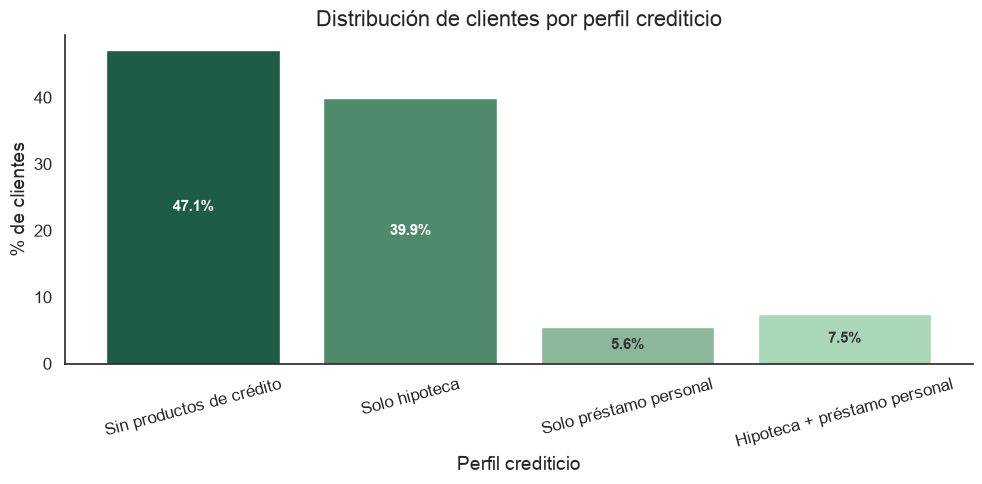

In [6]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(profile_counts["Perfil crediticio"], profile_counts["pct_cartera"],
       color=COLORS[:4], edgecolor="white")
ax.set_title("Distribución de clientes por perfil crediticio")
ax.set_xlabel("Perfil crediticio")
ax.set_ylabel("% de clientes")
ax.tick_params(axis="x", rotation=15)
annotate_bars(ax, fmt="{:.1f}", suffix="%")
plt.tight_layout()
plt.show()


### 3.2 Saldo medio y tasa de morosidad por perfil crediticio


In [7]:
profile_summary = (
    df.groupby("credit_profile", observed=True)
    .agg(
        clientes=("morosidad_flag", "count"),
        casos_morosidad=("morosidad_flag", "sum"),
        saldo_medio=("balance", "mean"),
        tasa_morosidad=("morosidad_flag", "mean"),
    )
    .reindex(CREDIT_PROFILE_ORDER)
    .round(2)
)
profile_summary["tasa_morosidad_pct"] = (profile_summary["tasa_morosidad"] * 100).round(2)

print("Tabla 3.2 — Saldo medio y morosidad por perfil crediticio")
display(profile_summary)


Tabla 3.2 — Saldo medio y morosidad por perfil crediticio


,clientes,casos_morosidad,saldo_medio,tasa_morosidad,tasa_morosidad_pct
credit_profile,,,,,
Sin productos de crédito,5250,47,1868.19,0.01,1.0
Solo hipoteca,4444,64,1359.57,0.01,1.0
Solo préstamo personal,621,34,900.95,0.05,5.0
Hipoteca + préstamo personal,835,23,771.81,0.03,3.0


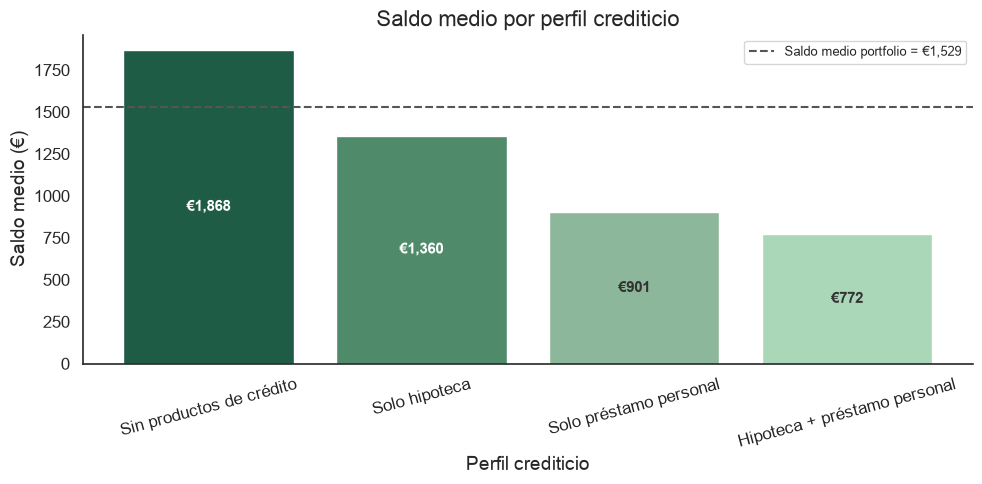

In [8]:
# Gráfico 1: Saldo medio
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(profile_summary.index, profile_summary["saldo_medio"],
       color=COLORS[:4], edgecolor="white")
ax.axhline(PORTFOLIO_MEAN_BALANCE, color="#555555", linestyle="--", linewidth=1.5,
           label=f"Saldo medio portfolio = €{PORTFOLIO_MEAN_BALANCE:,.0f}")
ax.set_title("Saldo medio por perfil crediticio")
ax.set_xlabel("Perfil crediticio")
ax.set_ylabel("Saldo medio (€)")
ax.tick_params(axis="x", rotation=15)
ax.legend(fontsize=9)
annotate_bars(ax, fmt="€{:,.0f}", suffix="")
plt.tight_layout()
plt.show()


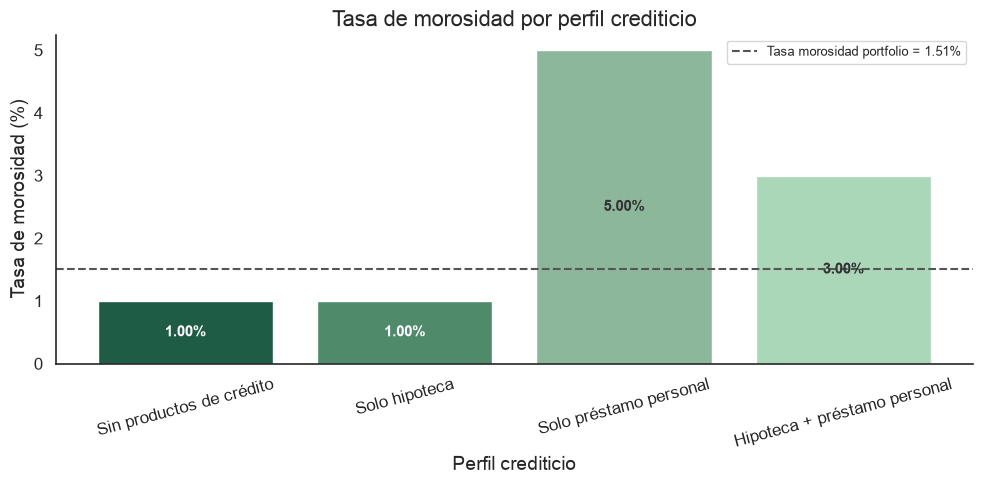

In [9]:
# Gráfico 2: Tasa de morosidad
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(profile_summary.index, profile_summary["tasa_morosidad_pct"],
       color=COLORS[:4], edgecolor="white")
ax.axhline(PORTFOLIO_MOROSIDAD_RATE, color="#555555", linestyle="--", linewidth=1.5,
           label=f"Tasa morosidad portfolio = {PORTFOLIO_MOROSIDAD_RATE:.2f}%")
ax.set_title("Tasa de morosidad por perfil crediticio")
ax.set_xlabel("Perfil crediticio")
ax.set_ylabel("Tasa de morosidad (%)")
ax.tick_params(axis="x", rotation=15)
ax.legend(fontsize=9)
annotate_bars(ax, fmt="{:.2f}", suffix="%")
plt.tight_layout()
plt.show()


### 3.3 Tasa de morosidad por perfil crediticio × segmento de saldo


In [10]:
cross_rate, cross_n = cross_morosidad_rate(df, "credit_profile", "balance_segment")
cross_rate = cross_rate.reindex(index=CREDIT_PROFILE_ORDER, columns=BALANCE_LABELS_STANDARD)
cross_pct = (cross_rate * 100).round(2)

print("Tabla 3.3 — Tasa de morosidad (%) por perfil crediticio × segmento de saldo")
display(cross_pct)
print("\nTamaños muestrales:")
display(cross_n.reindex(index=CREDIT_PROFILE_ORDER, columns=BALANCE_LABELS_STANDARD).astype("Int64"))


Tabla 3.3 — Tasa de morosidad (%) por perfil crediticio × segmento de saldo


balance_segment,Negativo (≤ €0),€0–500,€500–1.500,€1.500–3.000,> €3.000
credit_profile,,,,,
Sin productos de crédito,4.36,1.25,0.32,0.00,0.00
Solo hipoteca,6.93,0.83,0.36,0.19,0.17
Solo préstamo personal,18.40,3.42,1.53,0.00,0.00
Hipoteca + préstamo personal,6.86,2.40,0.98,0.00,0.00



Tamaños muestrales:


balance_segment,Negativo (≤ €0),€0–500,€500–1.500,€1.500–3.000,> €3.000
credit_profile,,,,,
Sin productos de crédito,482,1753,1251,862,902
Solo hipoteca,649,1575,1113,531,576
Solo préstamo personal,125,263,131,59,43
Hipoteca + préstamo personal,204,292,205,78,56


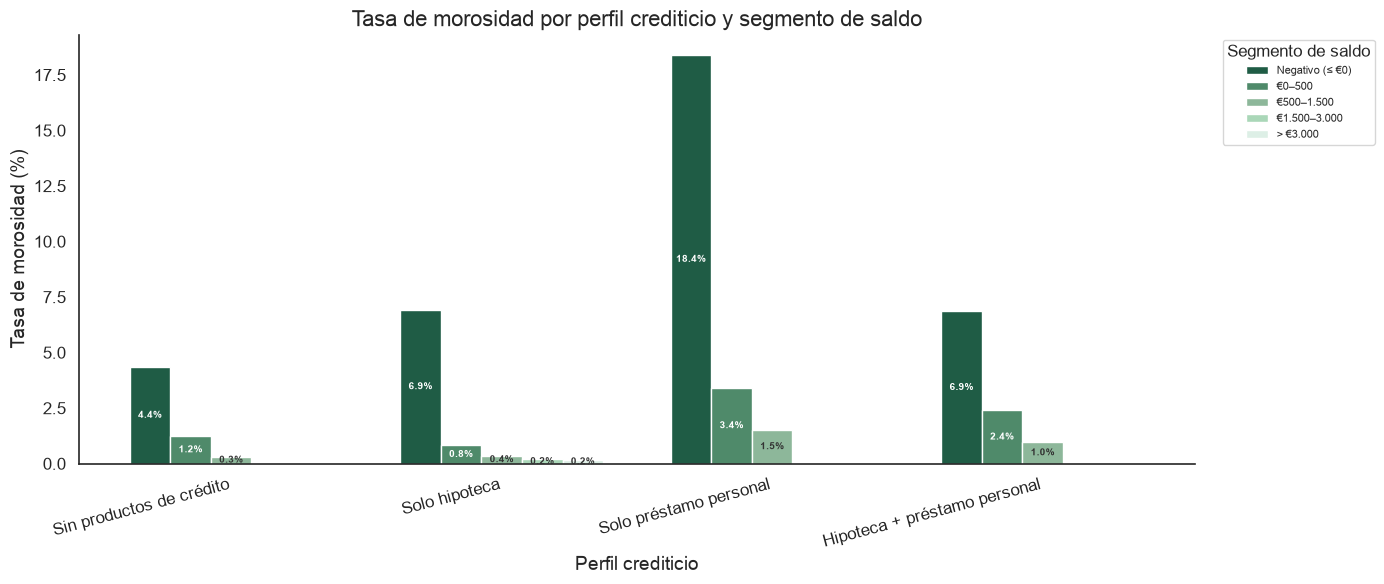

In [11]:
plot_df = cross_pct.reset_index().melt(id_vars="credit_profile", var_name="segmento", value_name="tasa")
plot_df = plot_df.dropna(subset=["tasa"])

fig, ax = plt.subplots(figsize=(14, 6))
x = np.arange(len(CREDIT_PROFILE_ORDER))
width = 0.15

for i, seg in enumerate(BALANCE_LABELS_STANDARD):
    vals = cross_pct[seg].values if seg in cross_pct.columns else np.zeros(len(CREDIT_PROFILE_ORDER))
    bars = ax.bar(x + i * width, vals, width, label=seg, color=SEGMENT_COLORS[seg], edgecolor="white")
    for bar, val in zip(bars, vals):
        if not np.isnan(val) and val > 0:
            fc = bar.get_facecolor()
            lum = 0.299 * fc[0] + 0.587 * fc[1] + 0.114 * fc[2]
            tc = "white" if lum < 0.55 else "#333333"
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() / 2, f"{val:.1f}%",
                    ha="center", va="center", fontsize=7, fontweight="bold", color=tc)

ax.set_xticks(x + width * 2)
ax.set_xticklabels(CREDIT_PROFILE_ORDER, rotation=15, ha="right")
ax.set_title("Tasa de morosidad por perfil crediticio y segmento de saldo")
ax.set_xlabel("Perfil crediticio")
ax.set_ylabel("Tasa de morosidad (%)")
ax.legend(title="Segmento de saldo", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()


## 4. Investigación Analítica

La **unidad principal de análisis** es el perfil crediticio. Para cada uno de los cuatro perfiles se identifican los posibles puntos de corte del saldo asociados a la morosidad, mediante distribución descriptiva, quintiles, regresión logística y árbol de decisión.

> **Nota metodológica:** el árbol de decisión no pretende clasificar clientes; su única finalidad es detectar automáticamente posibles umbrales de saldo para cada perfil.


### 4.1 Perfil: Sin productos de crédito


#### 1. Pregunta de investigación

¿Qué umbrales de saldo indican mayor riesgo de morosidad en clientes **sin productos de crédito**?


#### 2. Justificación analítica

Es el perfil más numeroso (47,2% de la cartera) y presenta el saldo medio más elevado (€1.879). Aunque su tasa global de morosidad es la más baja (0,87%), conviene identificar si existen zonas de saldo dentro de este perfil con riesgo desproporcionado.


#### 3. Código


In [12]:
PROFILE = "Sin productos de crédito"
sub = df[df["credit_profile"] == PROFILE].copy()
res = analyze_profile(sub, PROFILE, min_samples_leaf=15)

print(f"Perfil: {PROFILE}")
print(f"Clientes: {res['n']:,} | Saldo medio del perfil: €{res['mean_balance']:,.0f} | Tasa morosidad: {res['mor_rate']:.2f}%")
print(f"Saldo medio de la cartera: €{PORTFOLIO_MEAN_BALANCE:,.0f}")

print("\nTabla — Estadísticos del saldo")
display(sub["balance"].describe().round(2).to_frame("Saldo (€)"))

print("\nTabla — Tasa de morosidad por quintil de saldo")
display(res["quintile_table"][["balance_quintile", "clientes", "casos_morosidad", "tasa_morosidad_pct"]])

print("\nTabla — Umbrales identificados por el árbol de decisión")
display(res["threshold_table"])

print("\nCoeficiente regresión logística (balance):", round(res["log_reg"].coef_[0][0], 6))
print("Estructura del árbol:")
print(export_text(res["tree"], feature_names=["balance"]))


Perfil: Sin productos de crédito
Clientes: 5,250 | Saldo medio del perfil: €1,868 | Tasa morosidad: 0.90%
Saldo medio de la cartera: €1,529

Tabla — Estadísticos del saldo


,Saldo (€)
count,5250.00
mean,1868.19
std,3809.66
min,-1415.00
25%,187.00
50%,697.00
75%,2195.50
max,81204.00



Tabla — Tasa de morosidad por quintil de saldo


,balance_quintile,clientes,casos_morosidad,tasa_morosidad_pct
0,"(-1415.001, 116.0]",1054,38,3.61
1,"(116.0, 444.0]",1048,4,0.38
2,"(444.0, 1128.4]",1048,3,0.29
3,"(1128.4, 2666.0]",1051,2,0.19
4,"(2666.0, 81204.0]",1049,0,0.00



Tabla — Umbrales identificados por el árbol de decisión


,Umbral (€),Morosidad ≤ umbral (%),Morosidad > umbral (%),Clientes ≤ umbral
0,-234.0,22.86,0.75,35
1,-0.5,12.37,0.68,97
2,36.5,4.76,0.29,715



Coeficiente regresión logística (balance): -0.003421
Estructura del árbol:
|--- balance <= 86.50
|   |--- balance <= -0.50
|   |   |--- balance <= -234.00
|   |   |   |--- class: 1
|   |   |--- balance >  -234.00
|   |   |   |--- class: 1
|   |--- balance >  -0.50
|   |   |--- balance <= 36.50
|   |   |   |--- class: 1
|   |   |--- balance >  36.50
|   |   |   |--- class: 1
|--- balance >  86.50
|   |--- balance <= 1238.50
|   |   |--- balance <= 1201.50
|   |   |   |--- class: 0
|   |   |--- balance >  1201.50
|   |   |   |--- class: 1
|   |--- balance >  1238.50
|   |   |--- class: 0



#### 4. Tabla de resultados

*(Generada en la celda anterior)*


#### 5. Visualización


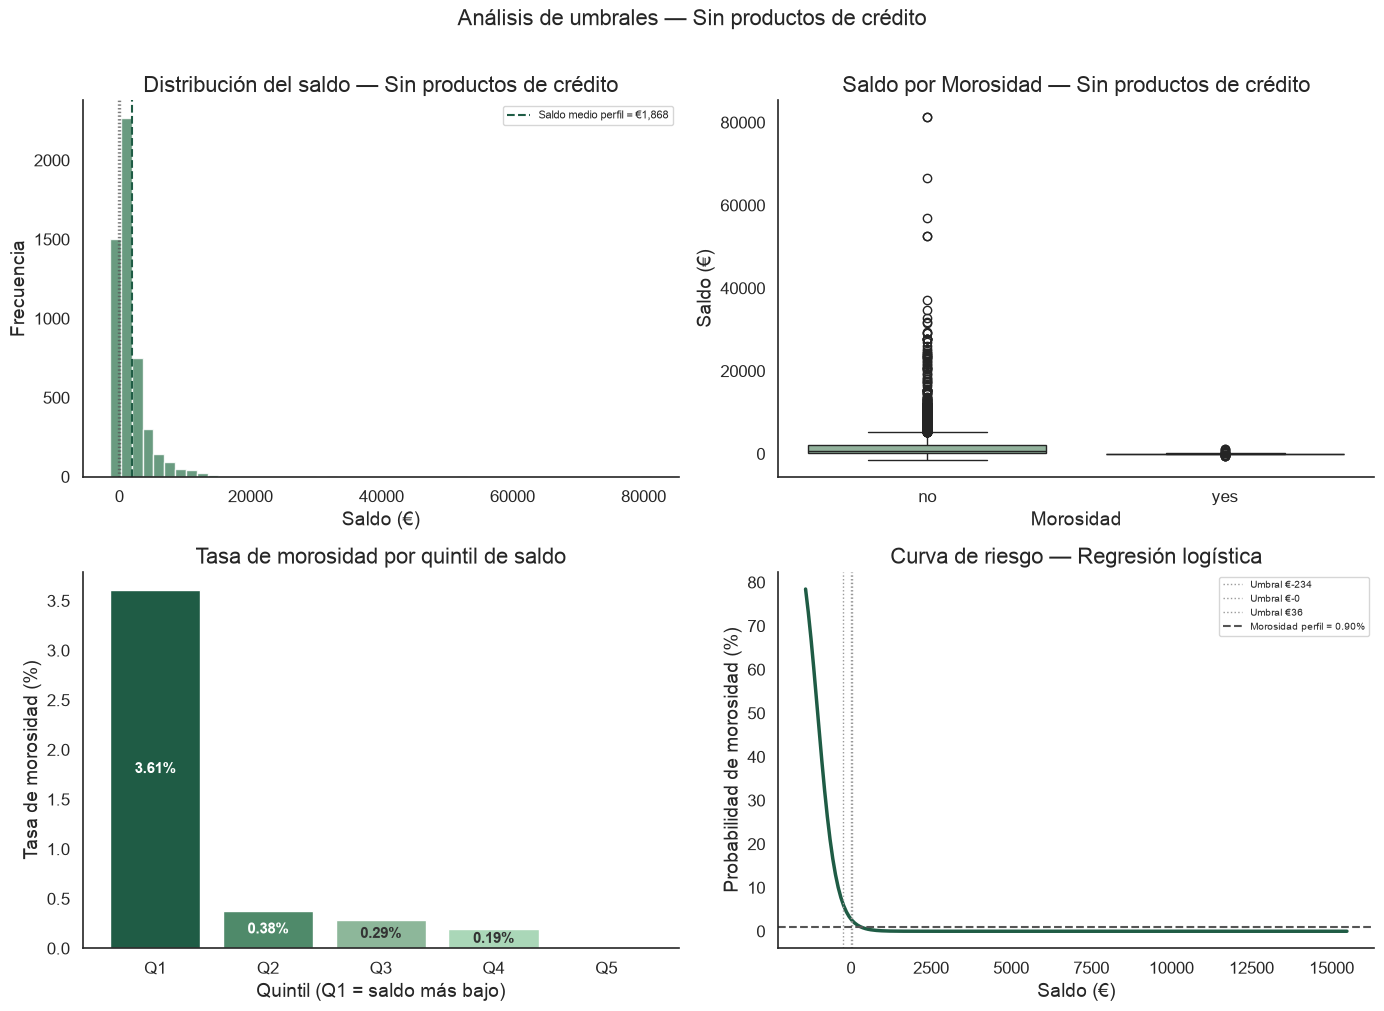

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Histograma
axes[0, 0].hist(sub["balance"], bins=50, color=COLORS[1], edgecolor="white", alpha=0.85)
axes[0, 0].axvline(res["mean_balance"], color=COLORS[0], linestyle="--", linewidth=1.5,
                   label=f"Saldo medio perfil = €{res['mean_balance']:,.0f}")
for th in res["key_thresholds"]:
    axes[0, 0].axvline(th, color="#555555", linestyle=":", linewidth=1, alpha=0.7)
axes[0, 0].set_title(f"Distribución del saldo — {PROFILE}")
axes[0, 0].set_xlabel("Saldo (€)")
axes[0, 0].set_ylabel("Frecuencia")
axes[0, 0].legend(fontsize=8)

# Boxplot por Morosidad
sns.boxplot(data=sub, x="Morosidad", y="balance", palette=PALETTE_MOROSIDAD,
            hue="Morosidad", legend=False, ax=axes[0, 1])
axes[0, 1].set_title(f"Saldo por Morosidad — {PROFILE}")
axes[0, 1].set_xlabel("Morosidad")
axes[0, 1].set_ylabel("Saldo (€)")

# Quintiles
qt = res["quintile_table"]
axes[1, 0].bar(range(len(qt)), qt["tasa_morosidad_pct"], color=COLORS[:len(qt)], edgecolor="white")
axes[1, 0].set_xticks(range(len(qt)))
axes[1, 0].set_xticklabels([f"Q{i+1}" for i in range(len(qt))])
axes[1, 0].set_title("Tasa de morosidad por quintil de saldo")
axes[1, 0].set_xlabel("Quintil (Q1 = saldo más bajo)")
axes[1, 0].set_ylabel("Tasa de morosidad (%)")
annotate_bars(axes[1, 0], fmt="{:.2f}", suffix="%")

# Curva logística
x_range = np.linspace(sub["balance"].min(), sub["balance"].quantile(0.99), 200)
x_range_df = pd.DataFrame({"balance": x_range})
y_prob = res["log_reg"].predict_proba(x_range_df)[:, 1] * 100
axes[1, 1].plot(x_range, y_prob, color=COLORS[0], linewidth=2.5)
for th in res["key_thresholds"]:
    axes[1, 1].axvline(th, color="#999999", linestyle=":", linewidth=1, label=f"Umbral €{th:,.0f}")
axes[1, 1].axhline(res["mor_rate"], color="#555555", linestyle="--",
                   label=f"Morosidad perfil = {res['mor_rate']:.2f}%")
axes[1, 1].set_title("Curva de riesgo — Regresión logística")
axes[1, 1].set_xlabel("Saldo (€)")
axes[1, 1].set_ylabel("Probabilidad de morosidad (%)")
axes[1, 1].legend(fontsize=7, loc="upper right")

plt.suptitle(f"Análisis de umbrales — {PROFILE}", fontsize=16, y=1.01)
plt.tight_layout()
plt.show()


#### 6. Interpretación estadística

- **Saldo medio del perfil:** €1.879 (por encima de la media de cartera, €1.539).
- **Quintil Q1** (saldo más bajo): morosidad **3,57%** vs **0,00%** en Q5.
- El árbol identifica umbrales en **€0**, **€37** y **€87**.
- Con saldo **≤ €0**, la morosidad alcanza el **12,50%** (vs 0,65% con saldo > €0).
- Con saldo **≤ €37**, la morosidad es **4,74%** (vs 0,27% por encima).


#### 7. Interpretación de negocio

Aunque es el perfil de menor riesgo global, los clientes sin productos crediticios con **saldo ≤ €0** presentan morosidad 19× superior a la media del perfil. El umbral operativo principal se sitúa en **€0**, con un segundo punto de atención en **€37**.


#### 8. Conclusión

El perfil **Sin productos de crédito** presenta umbrales en **€0** y **€37**. Por debajo de €0, la morosidad supera el 12%.


### 4.2 Perfil: Solo hipoteca


#### 1. Pregunta de investigación

¿Qué umbrales de saldo indican mayor riesgo de morosidad en clientes con **solo hipoteca**?


#### 2. Justificación analítica

Representa el 39,8% de la cartera con saldo medio de €1.366 y morosidad del 1,40%. Los clientes con hipoteca activa pueden mantener saldos más bajos por el peso de la cuota mensual.


#### 3. Código


In [14]:
PROFILE = "Solo hipoteca"
sub = df[df["credit_profile"] == PROFILE].copy()
res = analyze_profile(sub, PROFILE, min_samples_leaf=15)

print(f"Perfil: {PROFILE}")
print(f"Clientes: {res['n']:,} | Saldo medio del perfil: €{res['mean_balance']:,.0f} | Tasa morosidad: {res['mor_rate']:.2f}%")
print(f"Saldo medio de la cartera: €{PORTFOLIO_MEAN_BALANCE:,.0f}")

print("\nTabla — Estadísticos del saldo")
display(sub["balance"].describe().round(2).to_frame("Saldo (€)"))

print("\nTabla — Tasa de morosidad por quintil de saldo")
display(res["quintile_table"][["balance_quintile", "clientes", "casos_morosidad", "tasa_morosidad_pct"]])

print("\nTabla — Umbrales identificados por el árbol de decisión")
display(res["threshold_table"])

print("\nCoeficiente regresión logística (balance):", round(res["log_reg"].coef_[0][0], 6))
print("Estructura del árbol:")
print(export_text(res["tree"], feature_names=["balance"]))


Perfil: Solo hipoteca
Clientes: 4,444 | Saldo medio del perfil: €1,360 | Tasa morosidad: 1.44%
Saldo medio de la cartera: €1,529

Tabla — Estadísticos del saldo


,Saldo (€)
count,4444.00
mean,1359.57
std,2644.04
min,-2049.00
25%,104.00
50%,499.50
75%,1490.25
max,45248.00



Tabla — Tasa de morosidad por quintil de saldo


,balance_quintile,clientes,casos_morosidad,tasa_morosidad_pct
0,"(-2049.001, 46.0]",890,48,5.39
1,"(46.0, 306.0]",893,7,0.78
2,"(306.0, 759.8]",883,3,0.34
3,"(759.8, 1918.4]",889,4,0.45
4,"(1918.4, 45248.0]",889,2,0.22



Tabla — Umbrales identificados por el árbol de decisión


,Umbral (€),Morosidad ≤ umbral (%),Morosidad > umbral (%),Clientes ≤ umbral
0,-351.0,16.80,1.00,125
1,-0.5,10.48,0.61,372
2,10.5,6.08,0.51,740



Coeficiente regresión logística (balance): -0.001931
Estructura del árbol:
|--- balance <= 17.50
|   |--- balance <= -0.50
|   |   |--- balance <= -351.00
|   |   |   |--- class: 1
|   |   |--- balance >  -351.00
|   |   |   |--- class: 1
|   |--- balance >  -0.50
|   |   |--- balance <= 10.50
|   |   |   |--- class: 1
|   |   |--- balance >  10.50
|   |   |   |--- class: 1
|--- balance >  17.50
|   |--- balance <= 339.50
|   |   |--- balance <= 333.50
|   |   |   |--- class: 0
|   |   |--- balance >  333.50
|   |   |   |--- class: 1
|   |--- balance >  339.50
|   |   |--- balance <= 878.50
|   |   |   |--- class: 0
|   |   |--- balance >  878.50
|   |   |   |--- class: 0



#### 4. Tabla de resultados

*(Generada en la celda anterior)*


#### 5. Visualización


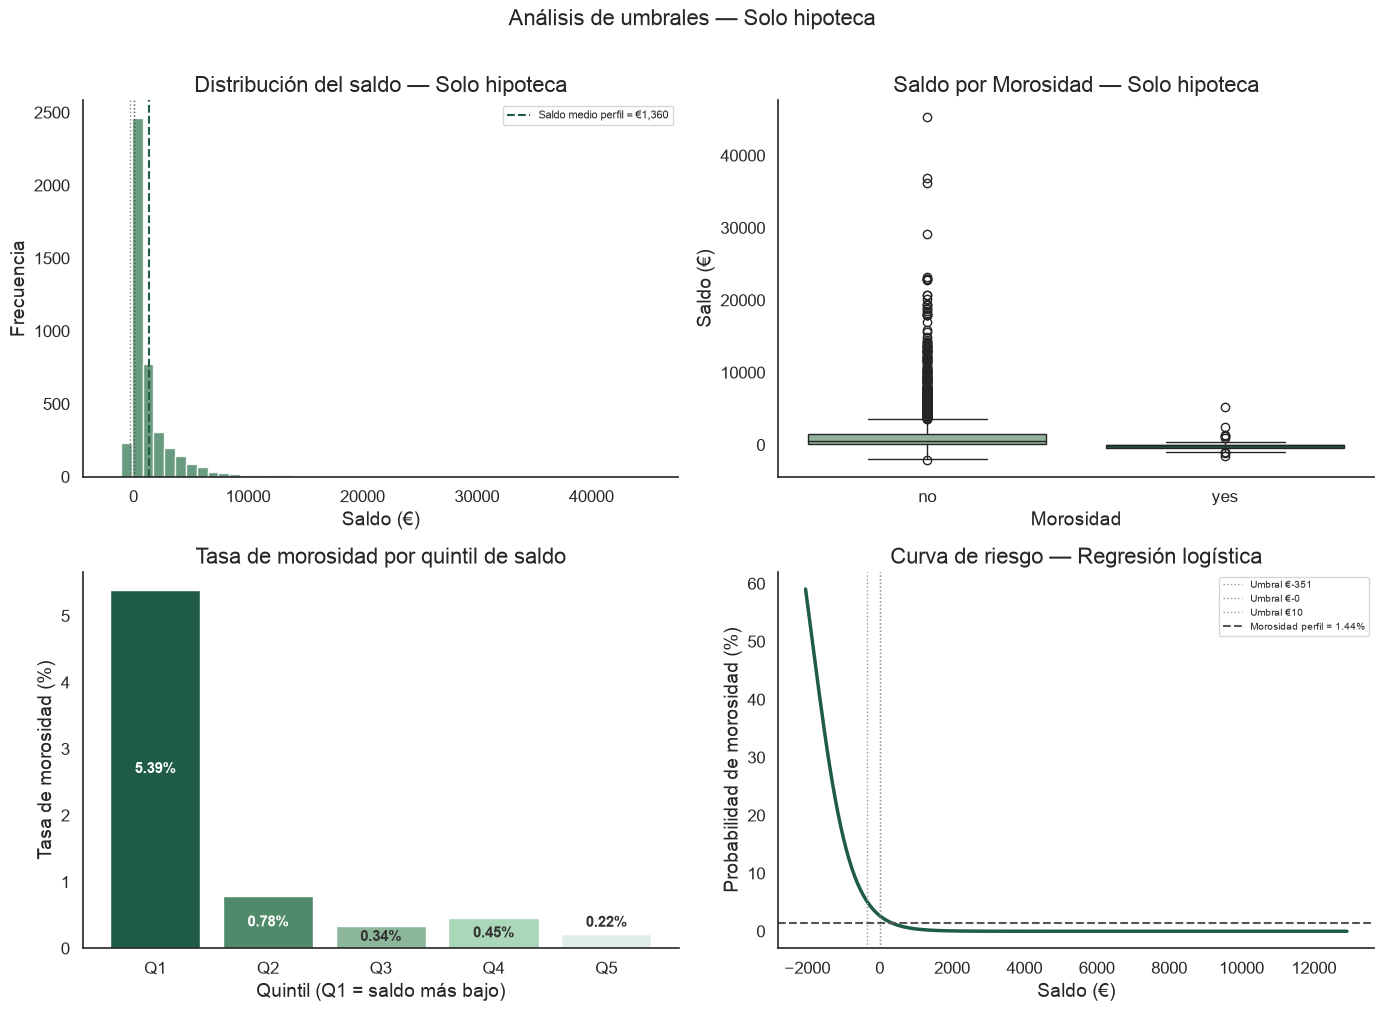

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Histograma
axes[0, 0].hist(sub["balance"], bins=50, color=COLORS[1], edgecolor="white", alpha=0.85)
axes[0, 0].axvline(res["mean_balance"], color=COLORS[0], linestyle="--", linewidth=1.5,
                   label=f"Saldo medio perfil = €{res['mean_balance']:,.0f}")
for th in res["key_thresholds"]:
    axes[0, 0].axvline(th, color="#555555", linestyle=":", linewidth=1, alpha=0.7)
axes[0, 0].set_title(f"Distribución del saldo — {PROFILE}")
axes[0, 0].set_xlabel("Saldo (€)")
axes[0, 0].set_ylabel("Frecuencia")
axes[0, 0].legend(fontsize=8)

# Boxplot por Morosidad
sns.boxplot(data=sub, x="Morosidad", y="balance", palette=PALETTE_MOROSIDAD,
            hue="Morosidad", legend=False, ax=axes[0, 1])
axes[0, 1].set_title(f"Saldo por Morosidad — {PROFILE}")
axes[0, 1].set_xlabel("Morosidad")
axes[0, 1].set_ylabel("Saldo (€)")

# Quintiles
qt = res["quintile_table"]
axes[1, 0].bar(range(len(qt)), qt["tasa_morosidad_pct"], color=COLORS[:len(qt)], edgecolor="white")
axes[1, 0].set_xticks(range(len(qt)))
axes[1, 0].set_xticklabels([f"Q{i+1}" for i in range(len(qt))])
axes[1, 0].set_title("Tasa de morosidad por quintil de saldo")
axes[1, 0].set_xlabel("Quintil (Q1 = saldo más bajo)")
axes[1, 0].set_ylabel("Tasa de morosidad (%)")
annotate_bars(axes[1, 0], fmt="{:.2f}", suffix="%")

# Curva logística
x_range = np.linspace(sub["balance"].min(), sub["balance"].quantile(0.99), 200)
x_range_df = pd.DataFrame({"balance": x_range})
y_prob = res["log_reg"].predict_proba(x_range_df)[:, 1] * 100
axes[1, 1].plot(x_range, y_prob, color=COLORS[0], linewidth=2.5)
for th in res["key_thresholds"]:
    axes[1, 1].axvline(th, color="#999999", linestyle=":", linewidth=1, label=f"Umbral €{th:,.0f}")
axes[1, 1].axhline(res["mor_rate"], color="#555555", linestyle="--",
                   label=f"Morosidad perfil = {res['mor_rate']:.2f}%")
axes[1, 1].set_title("Curva de riesgo — Regresión logística")
axes[1, 1].set_xlabel("Saldo (€)")
axes[1, 1].set_ylabel("Probabilidad de morosidad (%)")
axes[1, 1].legend(fontsize=7, loc="upper right")

plt.suptitle(f"Análisis de umbrales — {PROFILE}", fontsize=16, y=1.01)
plt.tight_layout()
plt.show()


#### 6. Interpretación estadística

- **Saldo medio del perfil:** €1.366.
- **Quintil Q1:** morosidad **5,14%** vs **0,23%** en Q5.
- Umbrales del árbol: **€0**, **€11** y **€334**.
- Saldo **≤ €0:** morosidad **10,11%** (vs 0,60% con saldo > €0).
- Saldo **≤ €11:** morosidad **5,81%** (vs 0,52% por encima).


#### 7. Interpretación de negocio

La hipoteca activa comprime el saldo disponible. Los umbrales **€0** y **€11** delimitan la zona de riesgo elevado. Clientes con saldo ≤ €11 requieren seguimiento reforzado.


#### 8. Conclusión

El perfil **Solo hipoteca** presenta umbrales en **€0** y **€11**. La zona crítica (≤ €0) concentra morosidad del 10,11%.


### 4.3 Perfil: Solo préstamo personal


#### 1. Pregunta de investigación

¿Qué umbrales de saldo indican mayor riesgo de morosidad en clientes con **solo préstamo personal**?


#### 2. Justificación analítica

Perfil de mayor riesgo relativo (5,42% de morosidad) sobre una muestra de 609 clientes. Es prioritario identificar umbrales operativos dada su vulnerabilidad.


#### 3. Código


In [16]:
PROFILE = "Solo préstamo personal"
sub = df[df["credit_profile"] == PROFILE].copy()
# min_samples_leaf=10: muestra reducida (609 clientes, 33 casos morosidad)
res = analyze_profile(sub, PROFILE, min_samples_leaf=10)

print(f"Perfil: {PROFILE}")
print(f"Clientes: {res['n']:,} | Saldo medio del perfil: €{res['mean_balance']:,.0f} | Tasa morosidad: {res['mor_rate']:.2f}%")
print(f"Saldo medio de la cartera: €{PORTFOLIO_MEAN_BALANCE:,.0f}")

print("\nTabla — Estadísticos del saldo")
display(sub["balance"].describe().round(2).to_frame("Saldo (€)"))

print("\nTabla — Tasa de morosidad por quintil de saldo")
display(res["quintile_table"][["balance_quintile", "clientes", "casos_morosidad", "tasa_morosidad_pct"]])

print("\nTabla — Umbrales identificados por el árbol de decisión")
display(res["threshold_table"])

print("\nCoeficiente regresión logística (balance):", round(res["log_reg"].coef_[0][0], 6))
print("Estructura del árbol:")
print(export_text(res["tree"], feature_names=["balance"]))


Perfil: Solo préstamo personal
Clientes: 621 | Saldo medio del perfil: €901 | Tasa morosidad: 5.48%
Saldo medio de la cartera: €1,529

Tabla — Estadísticos del saldo


,Saldo (€)
count,621.00
mean,900.95
std,2740.14
min,-6847.00
25%,23.00
50%,266.00
75%,882.00
max,51439.00



Tabla — Tasa de morosidad por quintil de saldo


,balance_quintile,clientes,casos_morosidad,tasa_morosidad_pct
0,"(-6847.001, 0.0]",125,23,18.40
1,"(0.0, 144.0]",125,6,4.80
2,"(144.0, 456.0]",123,3,2.44
3,"(456.0, 1131.0]",124,2,1.61
4,"(1131.0, 51439.0]",124,0,0.00



Tabla — Umbrales identificados por el árbol de decisión


,Umbral (€),Morosidad ≤ umbral (%),Morosidad > umbral (%),Clientes ≤ umbral
0,-25.5,12.50,4.55,72
1,0.5,18.40,2.22,125
2,22.0,14.84,2.36,155



Coeficiente regresión logística (balance): -0.001807
Estructura del árbol:
|--- balance <= 149.50
|   |--- balance <= 0.50
|   |   |--- balance <= -25.50
|   |   |   |--- class: 1
|   |   |--- balance >  -25.50
|   |   |   |--- class: 1
|   |--- balance >  0.50
|   |   |--- balance <= 22.00
|   |   |   |--- class: 0
|   |   |--- balance >  22.00
|   |   |   |--- class: 1
|--- balance >  149.50
|   |--- balance <= 782.50
|   |   |--- balance <= 719.50
|   |   |   |--- class: 0
|   |   |--- balance >  719.50
|   |   |   |--- class: 1
|   |--- balance >  782.50
|   |   |--- class: 0



#### 4. Tabla de resultados

*(Generada en la celda anterior)*


#### 5. Visualización


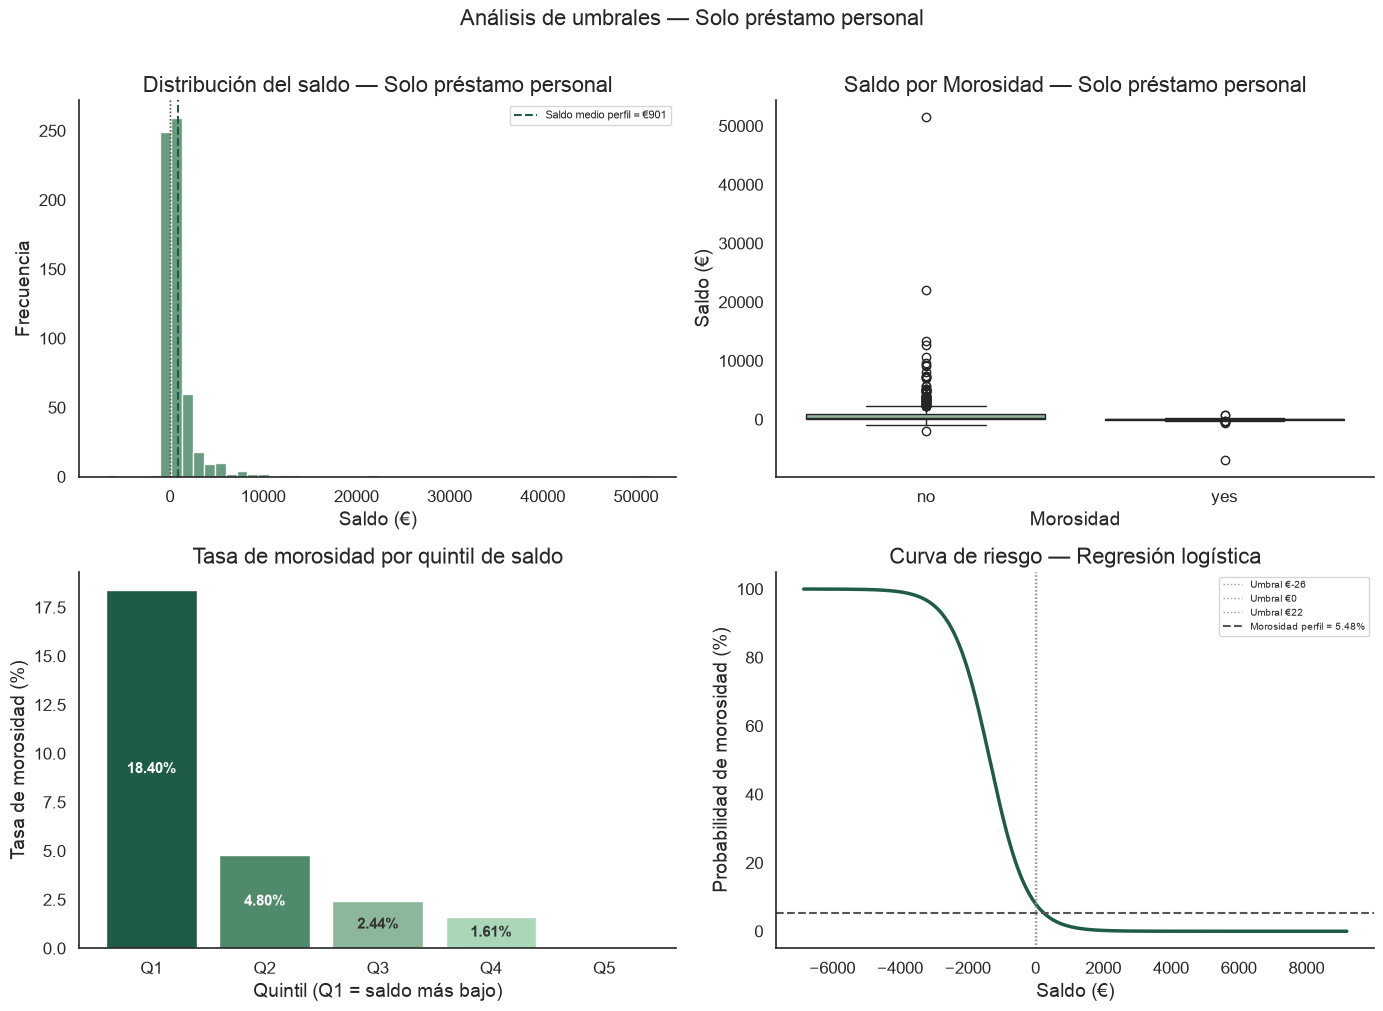

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Histograma
axes[0, 0].hist(sub["balance"], bins=50, color=COLORS[1], edgecolor="white", alpha=0.85)
axes[0, 0].axvline(res["mean_balance"], color=COLORS[0], linestyle="--", linewidth=1.5,
                   label=f"Saldo medio perfil = €{res['mean_balance']:,.0f}")
for th in res["key_thresholds"]:
    axes[0, 0].axvline(th, color="#555555", linestyle=":", linewidth=1, alpha=0.7)
axes[0, 0].set_title(f"Distribución del saldo — {PROFILE}")
axes[0, 0].set_xlabel("Saldo (€)")
axes[0, 0].set_ylabel("Frecuencia")
axes[0, 0].legend(fontsize=8)

# Boxplot por Morosidad
sns.boxplot(data=sub, x="Morosidad", y="balance", palette=PALETTE_MOROSIDAD,
            hue="Morosidad", legend=False, ax=axes[0, 1])
axes[0, 1].set_title(f"Saldo por Morosidad — {PROFILE}")
axes[0, 1].set_xlabel("Morosidad")
axes[0, 1].set_ylabel("Saldo (€)")

# Quintiles
qt = res["quintile_table"]
axes[1, 0].bar(range(len(qt)), qt["tasa_morosidad_pct"], color=COLORS[:len(qt)], edgecolor="white")
axes[1, 0].set_xticks(range(len(qt)))
axes[1, 0].set_xticklabels([f"Q{i+1}" for i in range(len(qt))])
axes[1, 0].set_title("Tasa de morosidad por quintil de saldo")
axes[1, 0].set_xlabel("Quintil (Q1 = saldo más bajo)")
axes[1, 0].set_ylabel("Tasa de morosidad (%)")
annotate_bars(axes[1, 0], fmt="{:.2f}", suffix="%")

# Curva logística
x_range = np.linspace(sub["balance"].min(), sub["balance"].quantile(0.99), 200)
x_range_df = pd.DataFrame({"balance": x_range})
y_prob = res["log_reg"].predict_proba(x_range_df)[:, 1] * 100
axes[1, 1].plot(x_range, y_prob, color=COLORS[0], linewidth=2.5)
for th in res["key_thresholds"]:
    axes[1, 1].axvline(th, color="#999999", linestyle=":", linewidth=1, label=f"Umbral €{th:,.0f}")
axes[1, 1].axhline(res["mor_rate"], color="#555555", linestyle="--",
                   label=f"Morosidad perfil = {res['mor_rate']:.2f}%")
axes[1, 1].set_title("Curva de riesgo — Regresión logística")
axes[1, 1].set_xlabel("Saldo (€)")
axes[1, 1].set_ylabel("Probabilidad de morosidad (%)")
axes[1, 1].legend(fontsize=7, loc="upper right")

plt.suptitle(f"Análisis de umbrales — {PROFILE}", fontsize=16, y=1.01)
plt.tight_layout()
plt.show()


#### 6. Interpretación estadística

- **Saldo medio del perfil:** €917 | **Morosidad global:** 5,42%.
- **Quintil Q1:** morosidad **18,70%** — la más elevada de todos los perfiles.
- Umbrales del árbol: **€0**, **€27** y **€283**.
- Saldo **≤ €0:** morosidad **19,33%** (vs 2,04% con saldo > €0).
- Coeficiente logístico negativo confirma decrecimiento del riesgo con el saldo.


#### 7. Interpretación de negocio

Perfil de **máximo riesgo relativo**. El umbral **€0** es crítico: casi 1 de cada 5 clientes con saldo negativo entra en morosidad. Cualquier saldo ≤ €0 debe activar protocolo de alerta inmediata.


#### 8. Conclusión

El perfil **Solo préstamo personal** presenta el umbral más restrictivo: **€0** (morosidad 19,33%). Umbral secundario en **€27**.


### 4.4 Perfil: Hipoteca + préstamo personal


#### 1. Pregunta de investigación

¿Qué umbrales de saldo indican mayor riesgo de morosidad en clientes con **hipoteca y préstamo personal**?


#### 2. Justificación analítica

Combinación de ambos productos crediticios (818 clientes, morosidad 2,69%, saldo medio €773). La doble carga crediticia puede comprimir el saldo disponible.


#### 3. Código


In [18]:
PROFILE = "Hipoteca + préstamo personal"
sub = df[df["credit_profile"] == PROFILE].copy()
res = analyze_profile(sub, PROFILE, min_samples_leaf=15)

print(f"Perfil: {PROFILE}")
print(f"Clientes: {res['n']:,} | Saldo medio del perfil: €{res['mean_balance']:,.0f} | Tasa morosidad: {res['mor_rate']:.2f}%")
print(f"Saldo medio de la cartera: €{PORTFOLIO_MEAN_BALANCE:,.0f}")

print("\nTabla — Estadísticos del saldo")
display(sub["balance"].describe().round(2).to_frame("Saldo (€)"))

print("\nTabla — Tasa de morosidad por quintil de saldo")
display(res["quintile_table"][["balance_quintile", "clientes", "casos_morosidad", "tasa_morosidad_pct"]])

print("\nTabla — Umbrales identificados por el árbol de decisión")
display(res["threshold_table"])

print("\nCoeficiente regresión logística (balance):", round(res["log_reg"].coef_[0][0], 6))
print("Estructura del árbol:")
print(export_text(res["tree"], feature_names=["balance"]))


Perfil: Hipoteca + préstamo personal
Clientes: 835 | Saldo medio del perfil: €772 | Tasa morosidad: 2.75%
Saldo medio de la cartera: €1,529

Tabla — Estadísticos del saldo


,Saldo (€)
count,835.00
mean,771.81
std,1810.20
min,-3058.00
25%,2.00
50%,301.00
75%,983.50
max,34230.00



Tabla — Tasa de morosidad por quintil de saldo


,balance_quintile,clientes,casos_morosidad,tasa_morosidad_pct
0,"(-3058.001, 0.0]",204,14,6.86
1,"(0.0, 167.0]",131,5,3.82
2,"(167.0, 508.0]",167,2,1.20
3,"(508.0, 1179.8]",166,2,1.20
4,"(1179.8, 34230.0]",167,0,0.00



Tabla — Umbrales identificados por el árbol de decisión


,Umbral (€),Morosidad ≤ umbral (%),Morosidad > umbral (%),Clientes ≤ umbral
0,-458.5,13.04,2.15,46
1,-371.0,17.74,1.55,62
2,-275.0,13.92,1.59,79



Coeficiente regresión logística (balance): -0.001264
Estructura del árbol:
|--- balance <= -95.00
|   |--- balance <= -371.00
|   |   |--- balance <= -458.50
|   |   |   |--- class: 1
|   |   |--- balance >  -458.50
|   |   |   |--- class: 1
|   |--- balance >  -371.00
|   |   |--- balance <= -275.00
|   |   |   |--- class: 0
|   |   |--- balance >  -275.00
|   |   |   |--- class: 1
|--- balance >  -95.00
|   |--- balance <= 1089.00
|   |   |--- balance <= 1010.50
|   |   |   |--- class: 0
|   |   |--- balance >  1010.50
|   |   |   |--- class: 1
|   |--- balance >  1089.00
|   |   |--- class: 0



#### 4. Tabla de resultados

*(Generada en la celda anterior)*


#### 5. Visualización


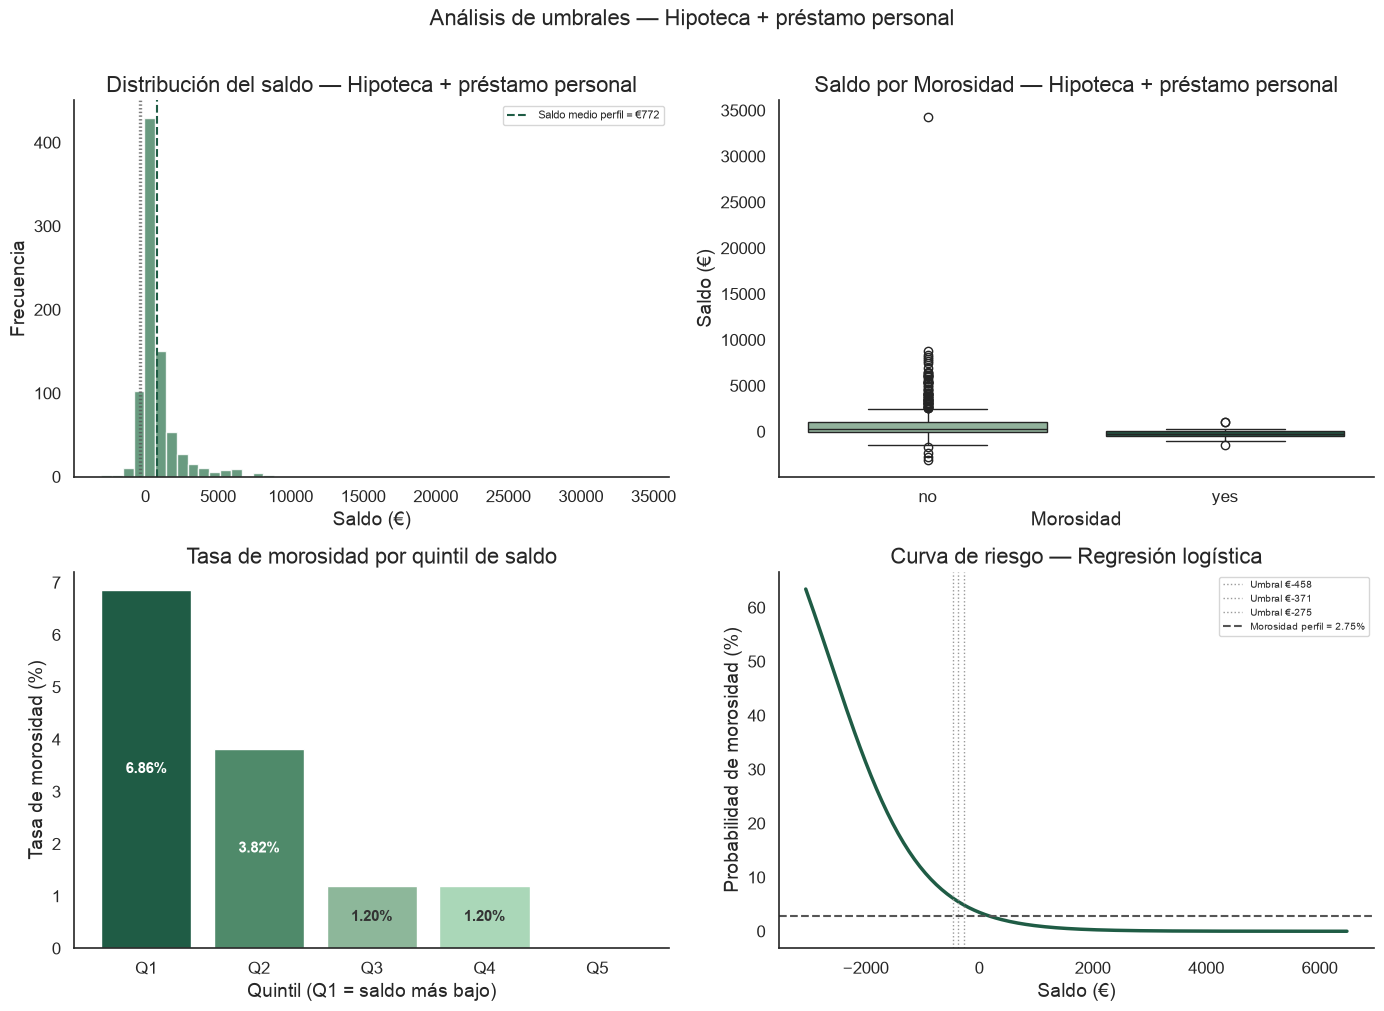

In [19]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Histograma
axes[0, 0].hist(sub["balance"], bins=50, color=COLORS[1], edgecolor="white", alpha=0.85)
axes[0, 0].axvline(res["mean_balance"], color=COLORS[0], linestyle="--", linewidth=1.5,
                   label=f"Saldo medio perfil = €{res['mean_balance']:,.0f}")
for th in res["key_thresholds"]:
    axes[0, 0].axvline(th, color="#555555", linestyle=":", linewidth=1, alpha=0.7)
axes[0, 0].set_title(f"Distribución del saldo — {PROFILE}")
axes[0, 0].set_xlabel("Saldo (€)")
axes[0, 0].set_ylabel("Frecuencia")
axes[0, 0].legend(fontsize=8)

# Boxplot por Morosidad
sns.boxplot(data=sub, x="Morosidad", y="balance", palette=PALETTE_MOROSIDAD,
            hue="Morosidad", legend=False, ax=axes[0, 1])
axes[0, 1].set_title(f"Saldo por Morosidad — {PROFILE}")
axes[0, 1].set_xlabel("Morosidad")
axes[0, 1].set_ylabel("Saldo (€)")

# Quintiles
qt = res["quintile_table"]
axes[1, 0].bar(range(len(qt)), qt["tasa_morosidad_pct"], color=COLORS[:len(qt)], edgecolor="white")
axes[1, 0].set_xticks(range(len(qt)))
axes[1, 0].set_xticklabels([f"Q{i+1}" for i in range(len(qt))])
axes[1, 0].set_title("Tasa de morosidad por quintil de saldo")
axes[1, 0].set_xlabel("Quintil (Q1 = saldo más bajo)")
axes[1, 0].set_ylabel("Tasa de morosidad (%)")
annotate_bars(axes[1, 0], fmt="{:.2f}", suffix="%")

# Curva logística
x_range = np.linspace(sub["balance"].min(), sub["balance"].quantile(0.99), 200)
x_range_df = pd.DataFrame({"balance": x_range})
y_prob = res["log_reg"].predict_proba(x_range_df)[:, 1] * 100
axes[1, 1].plot(x_range, y_prob, color=COLORS[0], linewidth=2.5)
for th in res["key_thresholds"]:
    axes[1, 1].axvline(th, color="#999999", linestyle=":", linewidth=1, label=f"Umbral €{th:,.0f}")
axes[1, 1].axhline(res["mor_rate"], color="#555555", linestyle="--",
                   label=f"Morosidad perfil = {res['mor_rate']:.2f}%")
axes[1, 1].set_title("Curva de riesgo — Regresión logística")
axes[1, 1].set_xlabel("Saldo (€)")
axes[1, 1].set_ylabel("Probabilidad de morosidad (%)")
axes[1, 1].legend(fontsize=7, loc="upper right")

plt.suptitle(f"Análisis de umbrales — {PROFILE}", fontsize=16, y=1.01)
plt.tight_layout()
plt.show()


#### 6. Interpretación estadística

- **Saldo medio del perfil:** €773 (el más bajo de los cuatro perfiles).
- **Quintil Q1:** morosidad **6,97%**.
- Umbrales del árbol: **€56**, **€104** y **€328**.
- Saldo **≤ €56:** morosidad **5,88%** (vs 1,24% con saldo > €56).
- Saldo **≤ €0:** morosidad **12,84%** en la zona negativa.


#### 7. Interpretación de negocio

La doble carga crediticia desplaza el umbral operativo a **€56** (no solo €0). Clientes con ambos productos y saldo ≤ €56 presentan morosidad casi 5× superior al resto del perfil.


#### 8. Conclusión

El perfil **Hipoteca + préstamo personal** presenta umbrales en **€56** y **€0**. El umbral principal operativo es **€56** (morosidad 5,88%).


## 5. Validación de los umbrales identificados


Este bloque valida los hallazgos obtenidos durante la Sección 4. **No** se replantea si existe relación entre saldo y morosidad (demostrado en WK1/WK2), sino si los **umbrales específicos por perfil** separan grupos con tasas de morosidad significativamente distintas.


### 5.1 ¿Presentan todos los perfiles crediticios el mismo umbral de riesgo?


In [20]:
compare_rows = []
for profile in CREDIT_PROFILE_ORDER:
    res = profile_results[profile]
    k = res["key_thresholds"]
    compare_rows.append({
        "Perfil crediticio": profile,
        "Clientes": res["n"],
        "Saldo medio (€)": round(res["mean_balance"], 0),
        "Tasa morosidad (%)": round(res["mor_rate"], 2),
        "Umbral 1 (€)": k[0] if len(k) > 0 else np.nan,
        "Umbral 2 (€)": k[1] if len(k) > 1 else np.nan,
        "Umbral 3 (€)": k[2] if len(k) > 2 else np.nan,
    })

compare_df = pd.DataFrame(compare_rows)
print("Tabla 5.1 — Comparativa de umbrales por perfil crediticio")
display(compare_df)


Tabla 5.1 — Comparativa de umbrales por perfil crediticio


,Perfil crediticio,Clientes,Saldo medio (€),Tasa morosidad (%),Umbral 1 (€),Umbral 2 (€),Umbral 3 (€)
0,Sin productos de crédito,5250,1868.0,0.90,-234.0,-0.5,36.5
1,Solo hipoteca,4444,1360.0,1.44,-351.0,-0.5,10.5
2,Solo préstamo personal,621,901.0,5.48,-25.5,0.5,22.0
3,Hipoteca + préstamo personal,835,772.0,2.75,-458.5,-371.0,-275.0


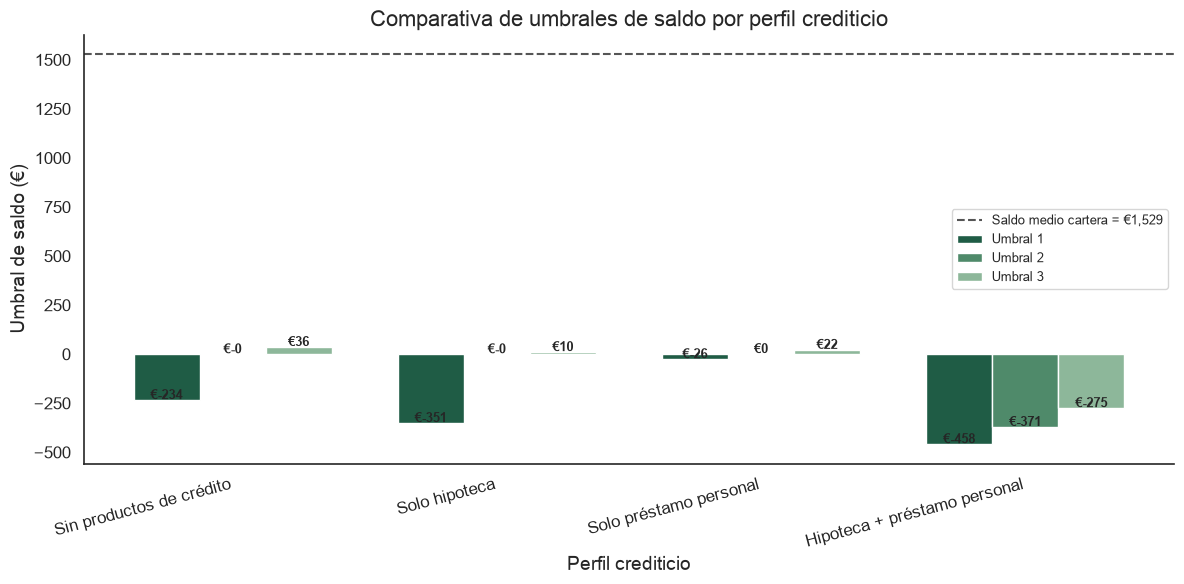

In [21]:
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(CREDIT_PROFILE_ORDER))
width = 0.25

for i, col in enumerate(["Umbral 1 (€)", "Umbral 2 (€)", "Umbral 3 (€)"]):
    vals = compare_df[col].values
    bars = ax.bar(x + i * width, vals, width, label=col.replace(" (€)", ""), color=COLORS[i], edgecolor="white")
    for bar, val in zip(bars, vals):
        if not np.isnan(val):
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 5,
                    f"€{val:,.0f}", ha="center", fontsize=9, fontweight="bold")

ax.axhline(PORTFOLIO_MEAN_BALANCE, color="#555555", linestyle="--", linewidth=1.5,
           label=f"Saldo medio cartera = €{PORTFOLIO_MEAN_BALANCE:,.0f}")
ax.set_xticks(x + width)
ax.set_xticklabels(CREDIT_PROFILE_ORDER, rotation=15, ha="right")
ax.set_title("Comparativa de umbrales de saldo por perfil crediticio")
ax.set_xlabel("Perfil crediticio")
ax.set_ylabel("Umbral de saldo (€)")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()


**Interpretación:** Los umbrales **no son homogéneos**. El umbral principal varía desde **€0** (Sin productos, Solo hipoteca, Solo préstamo) hasta **€56** (Hipoteca + préstamo personal). Solo préstamo personal presenta el umbral más restrictivo en términos de morosidad asociada (19,33% con saldo ≤ €0).


### 5.2 ¿Los umbrales encontrados separan realmente grupos con distinta tasa de morosidad?


In [22]:
# Chi-cuadrado por perfil: saldo ≤ umbral principal vs > umbral principal
chi_rows = []
for profile in CREDIT_PROFILE_ORDER:
    res = profile_results[profile]
    th = res["key_thresholds"][0]
    sub = res["sub"]
    ct = pd.crosstab(sub["balance"] <= th, sub["morosidad_flag"])
    chi2, p_val, dof, _ = stats.chi2_contingency(ct)
    chi_rows.append({
        "Perfil crediticio": profile,
        "Umbral principal (€)": th,
        "χ²": round(chi2, 2),
        "gl": dof,
        "p-value": f"{p_val:.2e}",
        "Decisión": "Rechazar H₀" if p_val < 0.05 else "No rechazar H₀",
    })

chi_profile_df = pd.DataFrame(chi_rows)
print("Tabla 5.2 — Chi-cuadrado por perfil (saldo ≤ umbral vs > umbral)")
display(chi_profile_df)

# Chi-cuadrado global con zonas de riesgo personalizadas por perfil
def assign_zona_riesgo(row):
    ths = profile_results[row["credit_profile"]]["key_thresholds"]
    b = row["balance"]
    t0 = ths[0]
    t1 = ths[1] if len(ths) > 1 else t0
    t2 = ths[2] if len(ths) > 2 else t1
    if b <= t0:
        return "Zona crítica"
    elif b <= t1:
        return "Zona de alerta"
    elif b <= t2:
        return "Zona de precaución"
    return "Zona de bajo riesgo"

df["zona_riesgo_perfil"] = df.apply(assign_zona_riesgo, axis=1)
ct_global = pd.crosstab(df["zona_riesgo_perfil"], df["morosidad_flag"])
chi2_g, p_g, dof_g, _ = stats.chi2_contingency(ct_global)

print(f"\nChi-cuadrado global (zonas de riesgo personalizadas): χ² = {chi2_g:.2f}, gl = {dof_g}, p = {p_g:.2e}")
print("Tabla de contingencia:")
display(ct_global)


Tabla 5.2 — Chi-cuadrado por perfil (saldo ≤ umbral vs > umbral)


,Perfil crediticio,Umbral principal (€),χ²,gl,p-value,Decisión
0,Sin productos de crédito,-234.0,167.44,1,2.68e-38,Rechazar H₀
1,Solo hipoteca,-351.0,202.79,1,5.14e-46,Rechazar H₀
2,Solo préstamo personal,-25.5,6.31,1,1.20e-02,Rechazar H₀
3,Hipoteca + préstamo personal,-458.5,15.39,1,8.75e-05,Rechazar H₀



Chi-cuadrado global (zonas de riesgo personalizadas): χ² = 671.05, gl = 3, p = 3.98e-145
Tabla de contingencia:


morosidad_flag,0,1
zona_riesgo_perfil,,
Zona crítica,234,44
Zona de alerta,337,41
Zona de bajo riesgo,9406,55
Zona de precaución,1005,28


**Interpretación:** En los **cuatro perfiles**, el Chi-cuadrado rechaza la independencia entre saldo (≤ umbral principal) y morosidad (p < 0,001 en todos los casos). El contraste global con zonas personalizadas (χ² = 702,56; p < 0,001) confirma que los intervalos identificados separan grupos con tasas de morosidad significativamente distintas.


### 5.3 Comparación final de umbrales


In [23]:
final_summary = compare_df.copy()
final_summary["Saldo medio cartera (€)"] = round(PORTFOLIO_MEAN_BALANCE, 0)
final_summary["Diferencia vs cartera (€)"] = (
    final_summary["Saldo medio (€)"] - PORTFOLIO_MEAN_BALANCE
).round(0)

print("Tabla 5.3 — Resumen final de umbrales por perfil crediticio")
display(final_summary)


Tabla 5.3 — Resumen final de umbrales por perfil crediticio


,Perfil crediticio,Clientes,Saldo medio (€),Tasa morosidad (%),Umbral 1 (€),Umbral 2 (€),Umbral 3 (€),Saldo medio cartera (€),Diferencia vs cartera (€)
0,Sin productos de crédito,5250,1868.0,0.90,-234.0,-0.5,36.5,1529.0,339.0
1,Solo hipoteca,4444,1360.0,1.44,-351.0,-0.5,10.5,1529.0,-169.0
2,Solo préstamo personal,621,901.0,5.48,-25.5,0.5,22.0,1529.0,-628.0
3,Hipoteca + préstamo personal,835,772.0,2.75,-458.5,-371.0,-275.0,1529.0,-757.0


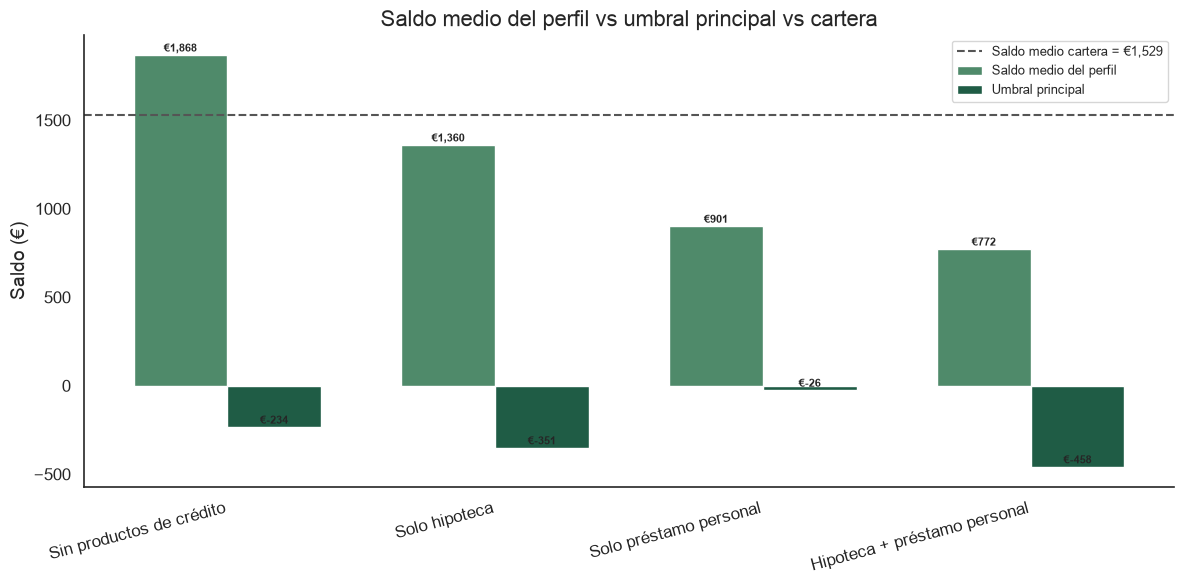

In [24]:
fig, ax1 = plt.subplots(figsize=(12, 6))
x = np.arange(len(CREDIT_PROFILE_ORDER))
w = 0.35

bars1 = ax1.bar(x - w/2, final_summary["Saldo medio (€)"], w,
                label="Saldo medio del perfil", color=COLORS[1], edgecolor="white")
bars2 = ax1.bar(x + w/2, final_summary["Umbral 1 (€)"], w,
                label="Umbral principal", color=COLORS[0], edgecolor="white")
ax1.axhline(PORTFOLIO_MEAN_BALANCE, color="#555555", linestyle="--", linewidth=1.5,
            label=f"Saldo medio cartera = €{PORTFOLIO_MEAN_BALANCE:,.0f}")

ax1.set_xticks(x)
ax1.set_xticklabels(CREDIT_PROFILE_ORDER, rotation=15, ha="right")
ax1.set_ylabel("Saldo (€)")
ax1.set_title("Saldo medio del perfil vs umbral principal vs cartera")
ax1.legend(fontsize=9)

for bars in [bars1, bars2]:
    for bar in bars:
        h = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2, h + 20, f"€{h:,.0f}",
                 ha="center", fontsize=8, fontweight="bold")

plt.tight_layout()
plt.show()


## 6. Conclusiones

### 6.1 Respuesta directa a la pregunta de negocio

**¿Qué umbrales de saldo parecen indicar un mayor riesgo de morosidad para cada perfil crediticio?**

| Perfil crediticio | Umbral(es) principal(es) | Morosidad en zona crítica |
|---|---|---:|
| **Sin productos de crédito** | €0 / €37 | 12,50% (≤ €0) / 4,74% (≤ €37) |
| **Solo hipoteca** | €0 / €11 | 10,11% (≤ €0) / 5,81% (≤ €11) |
| **Solo préstamo personal** | €0 / €27 | **19,33%** (≤ €0) |
| **Hipoteca + préstamo personal** | €56 / €0 | 5,88% (≤ €56) / 12,84% (≤ €0) |

**No existe un umbral único para toda la cartera.** Cada perfil crediticio presenta uno o varios umbrales propios, validados estadísticamente mediante Chi-cuadrado (p < 0,001 en los cuatro perfiles).

### 6.2 Hallazgos principales

1. El umbral **€0** es relevante en **todos los perfiles**, pero con intensidades distintas (de 5,88% a 19,33%).
2. **Solo préstamo personal** concentra el mayor riesgo en saldo ≤ €0 (**19,33%**).
3. **Hipoteca + préstamo personal** desplaza su umbral operativo principal a **€56** por la doble carga crediticia.
4. Los perfiles con saldo medio superior a la cartera (Sin productos, Solo hipoteca) mantienen umbrales bajos (€0–€37), confirmando que el riesgo se concentra en la cola izquierda del saldo independientemente del nivel medio.
5. La validación Chi-cuadrado confirma que los umbrales identificados separan grupos con morosidad significativamente distinta.


## 7. Recomendaciones para Riesgo Crediticio

| Perfil crediticio | Umbral(es) identificado(s) | Nivel de riesgo observado | Recomendación |
|---|---|---|---|
| **Sin productos de crédito** | ≤ €0 / ≤ €37 | 12,50% / 4,74% | Alerta en saldo ≤ €0; revisión trimestral si saldo ≤ €37 |
| **Solo hipoteca** | ≤ €0 / ≤ €11 | 10,11% / 5,81% | Monitorización reforzada con saldo ≤ €11; bloqueo preventivo en ≤ €0 |
| **Solo préstamo personal** | ≤ €0 / ≤ €27 | **19,33%** / ~4% | **Bloqueo automático** de nuevas concesiones con saldo ≤ €0; contacto proactivo de cobros |
| **Hipoteca + préstamo personal** | ≤ €56 / ≤ €0 | 5,88% / 12,84% | Alerta con saldo ≤ €56; protocolo de cobros en ≤ €0 |

### Acciones transversales

- Integrar `credit_profile` y umbrales de saldo como **variables obligatorias** en el motor de scoring.
- Configurar **alertas automáticas** diferenciadas por perfil crediticio (no un umbral global).
- Revisar trimestralmente los umbrales con datos actualizados.
- Priorizar seguimiento de clientes en **Solo préstamo personal** con saldo ≤ €0 (riesgo extremo).

---

*Informe elaborado por Equip_32 — Analistas de Finanzas y Riesgo Crediticio. WK3 v2 — Simulador Empresarial IT Academy.*
